https://github.com/FabricioArendTorres/FlowConductor/tree/main

In [1]:
%load_ext autoreload
%autoreload 2

import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow

from msi.utils import preprocessing, plotting, diagnostics
from msfm.utils import prior, parameters, files, logger, observation

# load network predictions

# v14

### lensing

In [2]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
# # first v14 run
# model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default"
# # n_steps = 100_000
# # n_steps = 200_000
# # n_steps = 300_000
# n_steps = 400_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

### clustering

In [3]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
# # first v14 clustering probes run
# model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default"
# # n_steps = 80_000
# # n_steps = 160_000
# n_steps = 240_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}

### combined

In [4]:
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
# base_dir = ""

# # mutual info loss ###############################################################################################

# # grateful-universe-1093 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/tun9hdvl/overview)
# # mythical-cantina-1094 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/6w6yju8t/overview)
# # first v14 combined probes run
# model_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/combined/mutual_info/2025-04-30_02-27-42_deepsphere_default"
# # n_steps = 100_000
# # n_steps = 200_000
# # n_steps = 300_000
# n_steps = 400_000

# # fisher info loss ###############################################################################################

# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}

# v15

In [5]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v15/extended.yaml")

### lensing

In [6]:
# likely-vortex-1179 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/9d63ista/overview)
model_dir = "/pscratch/sd/a/athomsen/run_files/v15/extended/lensing/mutual_info/default/v2"
# n_steps = 200_000
n_steps = 400_000
# n_steps = 450_000
# n_steps = 600_000

checkpoint_number = n_steps // 10_000
n_z = 4
lensing = True

params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0}

### combined

In [7]:
# # deep-sound-1177 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/kqj560dy/overview)
# model_dir = "/pscratch/sd/a/athomsen/run_files/v15/extended/combined/mutual_info/default/v1"
# # n_steps = 440_000
# n_steps = 520_000

# checkpoint_number = n_steps // 10_000
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# buzzard_cosmo = {"Om": 0.286, "s8": 0.82, "w0": -1, "Aia": 0.0, "n_Aia": np.nan, "bta": 0.0, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan}
# n_z = 8
# combined = True

### general

In [8]:
base_dir = ""

# dataset
fidu_preds, grid_preds, grid_cosmos, file_dict = preprocessing.get_reshaped_network_preds(
    base_dir,
    model_dir,
    n_steps,
    with_fidu=False,
)

# output directory and file names
out_dir = os.path.join(base_dir, model_dir)

label = f"{n_steps}_steps"

26-02-20 02:22:25 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/run_files/v15/extended/lensing/mutual_info/default/v2/preds_400000.h5 
26-02-20 02:22:25 input_output INF   Array shapes: 
26-02-20 02:22:25 input_output INF   fiducial/vali/pred = (40000, 12) 
26-02-20 02:22:25 input_output INF   fiducial/vali/i_example = (40000,) 
26-02-20 02:22:25 input_output INF   fiducial/vali/i_noise = (40000,) 
26-02-20 02:22:25 input_output INF   grid/pred          = (2500, 80, 12) 
26-02-20 02:22:25 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-02-20 02:22:25 input_output INF   grid/i_example     = (2500, 80) 
26-02-20 02:22:25 input_output INF   grid/i_noise       = (2500, 80) 
26-02-20 02:22:25 input_output INF   grid/i_sobol       = (2500, 80) 


26-02-20 02:22:25 preprocessin INF   Shapes after concatenation and selection: 
26-02-20 02:22:25 preprocessin INF   grid_preds  = (200000, 12) 
26-02-20 02:22:25 preprocessin INF   grid_cosmos = (200000, 6) 


# likelihood Flow $p(x|\theta)$

### architecture

In [9]:
model = LikelihoodFlow(
    params, 
    conf, 
    feature_dim=grid_preds.shape[-1],
    out_dir=out_dir,
    label=label,
    load_existing=True,
)

26-02-20 02:22:25 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v15/extended/lensing/mutual_info/default/v2/400000_steps/likelihood_flow 
26-02-20 02:22:25 likelihood_f INF   Using the default context embedding network: 
26-02-20 02:22:25 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
26-02-20 02:22:25 likelihood_f INF   Using the default base distribution: 
26-02-20 02:22:25 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-02-20 02:22:25 likelihood_f INF   Using the default transform: 
26-02-20 02:22:25 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
26-02-20 02:22:25 likelihood_f INF   Initialized the normalizing flow 
26-02-20 02:22:25 likelihood_f INF   Running on device cuda with default float torch.float32 
26-02-20 02:22:25 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v15/extended/lensing/mutual_info/default/v2/400000_steps/likelihood_flow/likeli

### training

In [10]:
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     batch_size=10_000,
#     scheduler_type="cosine",
#     save_model=True,
# )

# contours

## observations

### CosmoGrid internal

grid 

In [11]:
# obs_dict = {}

# shift = 5
# # n_examples = 4
# n_examples = 16
# i_fidu = 0

# for i_grid in range(n_examples):
#     i_grid *= 80
#     obs_dict[f"grid_{i_grid}"] = {
#         "pred": grid_preds[i_grid],
#         "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     }

# # i_grid = 99
# # obs_dict[f"grid_{i_grid}"] = {
# #     "pred": grid_preds[i_grid],
# #     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
# # }

separate

In [12]:
# obs_dict = {}
# mock_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))}

# # mock_labels = ["bench_fidu"]
# # mock_labels += ["bench_box", "bench_particle", "bench_redshift"]
# # mock_labels += ["source_clustering_bgs_low", "source_clustering_bgs_high"]
# # mock_labels = ["ia_shell"]

# # mock_labels = ["Aia=0", "Aia=1", "Aia=-1"]
# # mock_labels = ["fidu_bary", "fidu_dmo"]
# # mock_labels = ["bench_fidu", "bench_fidu_seed=1234"]
# # mock_labels = ["bench_fidu_dmo"]

# # mock_labels = ["bench_fidu", "reduced_shear"]

# # mock_labels = ["ia_bin", "ia_shell"]

# mock_labels = ["no_mag", "mag"]
# # mock_labels = ["sys_ref", "sys_cont"]

# for mock_label in mock_labels:
#     if mock_label == "Aia=0":
#         mock_cosmo["Aia"] = 0.0
#         mock_cosmo["n_Aia"] = 0.0
#     elif mock_label == "Aia=1":
#         mock_cosmo["Aia"] = 1.0
#         mock_cosmo["n_Aia"] = 0.0
#     elif mock_label == "Aia=-1":
#         mock_cosmo["Aia"] = -1.0
#         mock_cosmo["n_Aia"] = 0.0
#     elif "ia_" in mock_label:
#         mock_cosmo["Aia"] = 1.0
#         mock_cosmo["n_Aia"] = 1.0

#     mock_preds = file_dict[f"mocks/pred/{mock_label}"]
    
#     obs_dict[f"{mock_label}_mean"] = {
#         "pred": np.mean(mock_preds, axis=0), 
#         "point": mock_cosmo,
#     }
    
#     # obs_dict[f"{mock_label}_[0,15]_stack"] = {
#     #     "pred": mock_preds[0:15], 
#     #     "point": mock_cosmo,
#     # }

### external

In [13]:
obs_dict = {}

suffix = ""

buzzard_stack = []
buzzard_indices = list(range(0, 16))
buzzard_indices.remove(1)
# buzzard_indices.remove(10)
# buzzard_indices = [0, 2, 3, 4]
for i in buzzard_indices:
    pred = np.squeeze(file_dict[f"mocks/pred/Buzzard_{i}" + suffix])
    buzzard_stack.append(pred)

    # obs_dict[f"Buzzard_{i}" + suffix] = {
    #     "pred": pred,
    #     "point": buzzard_cosmo,
    # }

buzzard_stack = np.stack(buzzard_stack, axis=0)
    
obs_dict[f"Buzzard_mean" + suffix] = {
    "pred": np.mean(buzzard_stack, axis=0),
    "point": buzzard_cosmo,
}

# obs_dict[f"Buzzard_stack" + suffix] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "point": buzzard_cosmo,
# }

### MCMC and plotting


Starting with mock observation Buzzard_mean
[-0.6982263  -4.2416234   0.07725937 -3.6591496  -0.15327422  1.2145473
 -0.6395239  -0.68421936 -0.49278432  0.20242395  2.1410336   6.658408  ]
26-02-20 02:31:09 likelihood_f INF   Sampling the posterior from a single observation 
26-02-20 02:31:09 likelihood_f WAR   lambdaCDM 
26-02-20 02:31:09      mcmc.py INF   Initial values in prior: 47.5% 
26-02-20 02:31:09      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:24<00:00, 41.30it/s]

26-02-20 02:31:33      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:24<00:00, 41.57it/s]

26-02-20 02:31:57      mcmc.py INF   MAP parameters: {'Om': 0.289, 's8': 0.816, 'Aia': 0.391, 'n_Aia': 2.156, 'bta': 0.685} 


...

  0%|          | 0/15 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


  0%|          | 0/15 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/utils_plots.py:650: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  lis, las = ax[i, j].get_legend_handles_labels()


26-02-20 02:32:04  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v15/extended/lensing/mutual_info/default/v2/400000_steps/likelihood_flow/contours_Buzzard_mean_lambdaCDM.png 


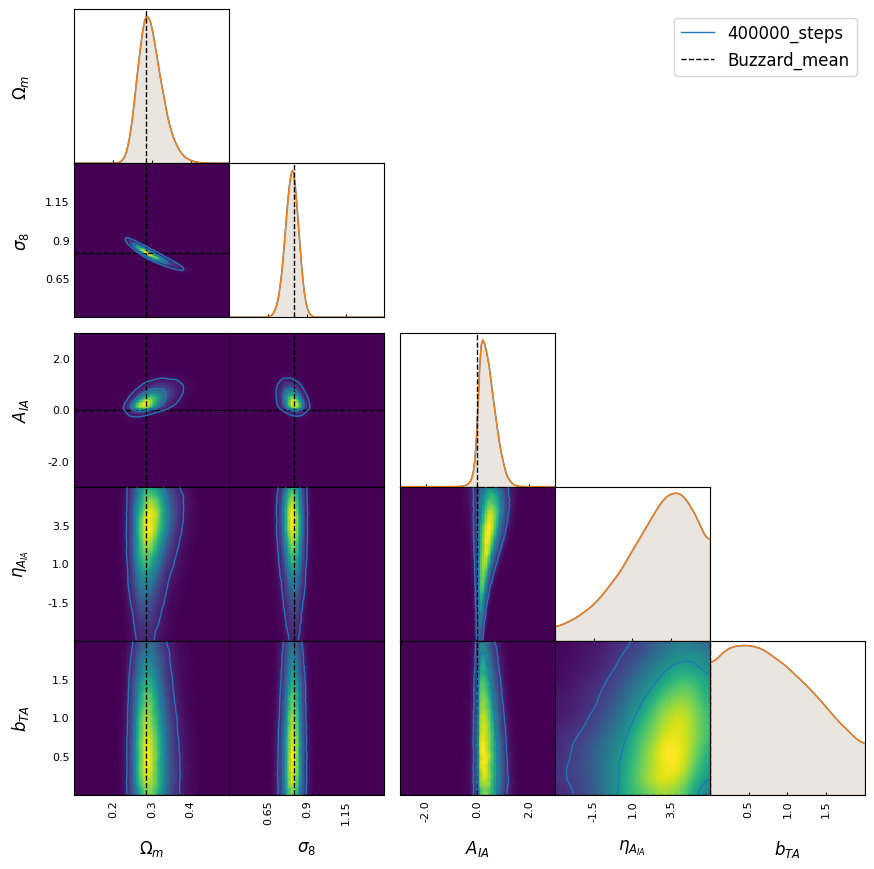

In [19]:
extra_label = ""
# lambdaCDM = False
lambdaCDM = True

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    print(obs_dict[key]["pred"])
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_steps=1000,
        n_burnin_steps=1000,
        lambdaCDM=lambdaCDM,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key+extra_label,
        with_des_chain=False,
        density=True,
        lambdaCDM=lambdaCDM,
    )